In [1]:
import pandas as pb
import numpy as np

from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from datasets import load_dataset
from huggingface_hub import hf_hub_download

import utils

/home/maciej/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
onehot_events_df = utils.read_and_onehot_events("../data-processing/events.csv")

In [3]:
# Load dataset splits
train_dataset = load_dataset("sookiemonster/asrs-narratives", split="train")
validation_dataset = load_dataset("sookiemonster/asrs-narratives", split="validation")
test_dataset = load_dataset("sookiemonster/asrs-narratives", split="test")

train_acns = set(train_dataset["acn"])
validation_acns = set(validation_dataset["acn"])
test_acns = set(test_dataset["acn"])

print(len(train_acns))
print(len(validation_acns))
print(len(test_acns))

10360
4441
9868


In [4]:
# Split up the main dataframe
train_events_df = onehot_events_df.iloc[onehot_events_df.index.isin(train_acns)]
validation_events_df = onehot_events_df.iloc[onehot_events_df.index.isin(validation_acns)]
test_events_df = onehot_events_df.iloc[onehot_events_df.index.isin(test_acns)]

print(len(train_events_df))
print(len(validation_events_df))
print(len(test_events_df))

10293
4415
9826


One vs. Rest Classification (With SVMs) - Unbalanced

In [5]:
svc = SVC()
ovr = OneVsRestClassifier(svc, n_jobs=-1) # n-jobs = -1 to use all available processors in parallel

In [6]:
trainX = train_events_df.drop(columns="assessments_primary_problem")
trainY = train_events_df["assessments_primary_problem"]

testX = test_events_df.drop(columns="assessments_primary_problem")
testY = test_events_df["assessments_primary_problem"]

In [7]:
ovr.fit(trainX, trainY)

,estimator,SVC()
,n_jobs,-1
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001


In [8]:
ovr.score(testX, testY)

0.6830856910238143

/home/maciej/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/maciej/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/maciej/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                                              precision    recall  f1-score   support

                                    aircraft       0.81      0.95      0.88      3286
                                     airport       0.47      0.36      0.41       244
                          airspace_structure       0.48      0.09      0.14       129
                                   ambiguous       0.50      0.27      0.36       795
    atc_equipment_/_nav_facility_/_buildings       0.49      0.40      0.44       126
                        chart_or_publication       0.47      0.26      0.34       134
                              company_policy       0.20      0.06      0.09        53
           environment___non_weather_related       0.47      0.11      0.17       238
                         equipment_/_tooling       0.19      0.11      0.14        38
                               human_factors       0.63      0.85      0.73      3359
incorrect_/_not_installed_/_unavailable_part       1.

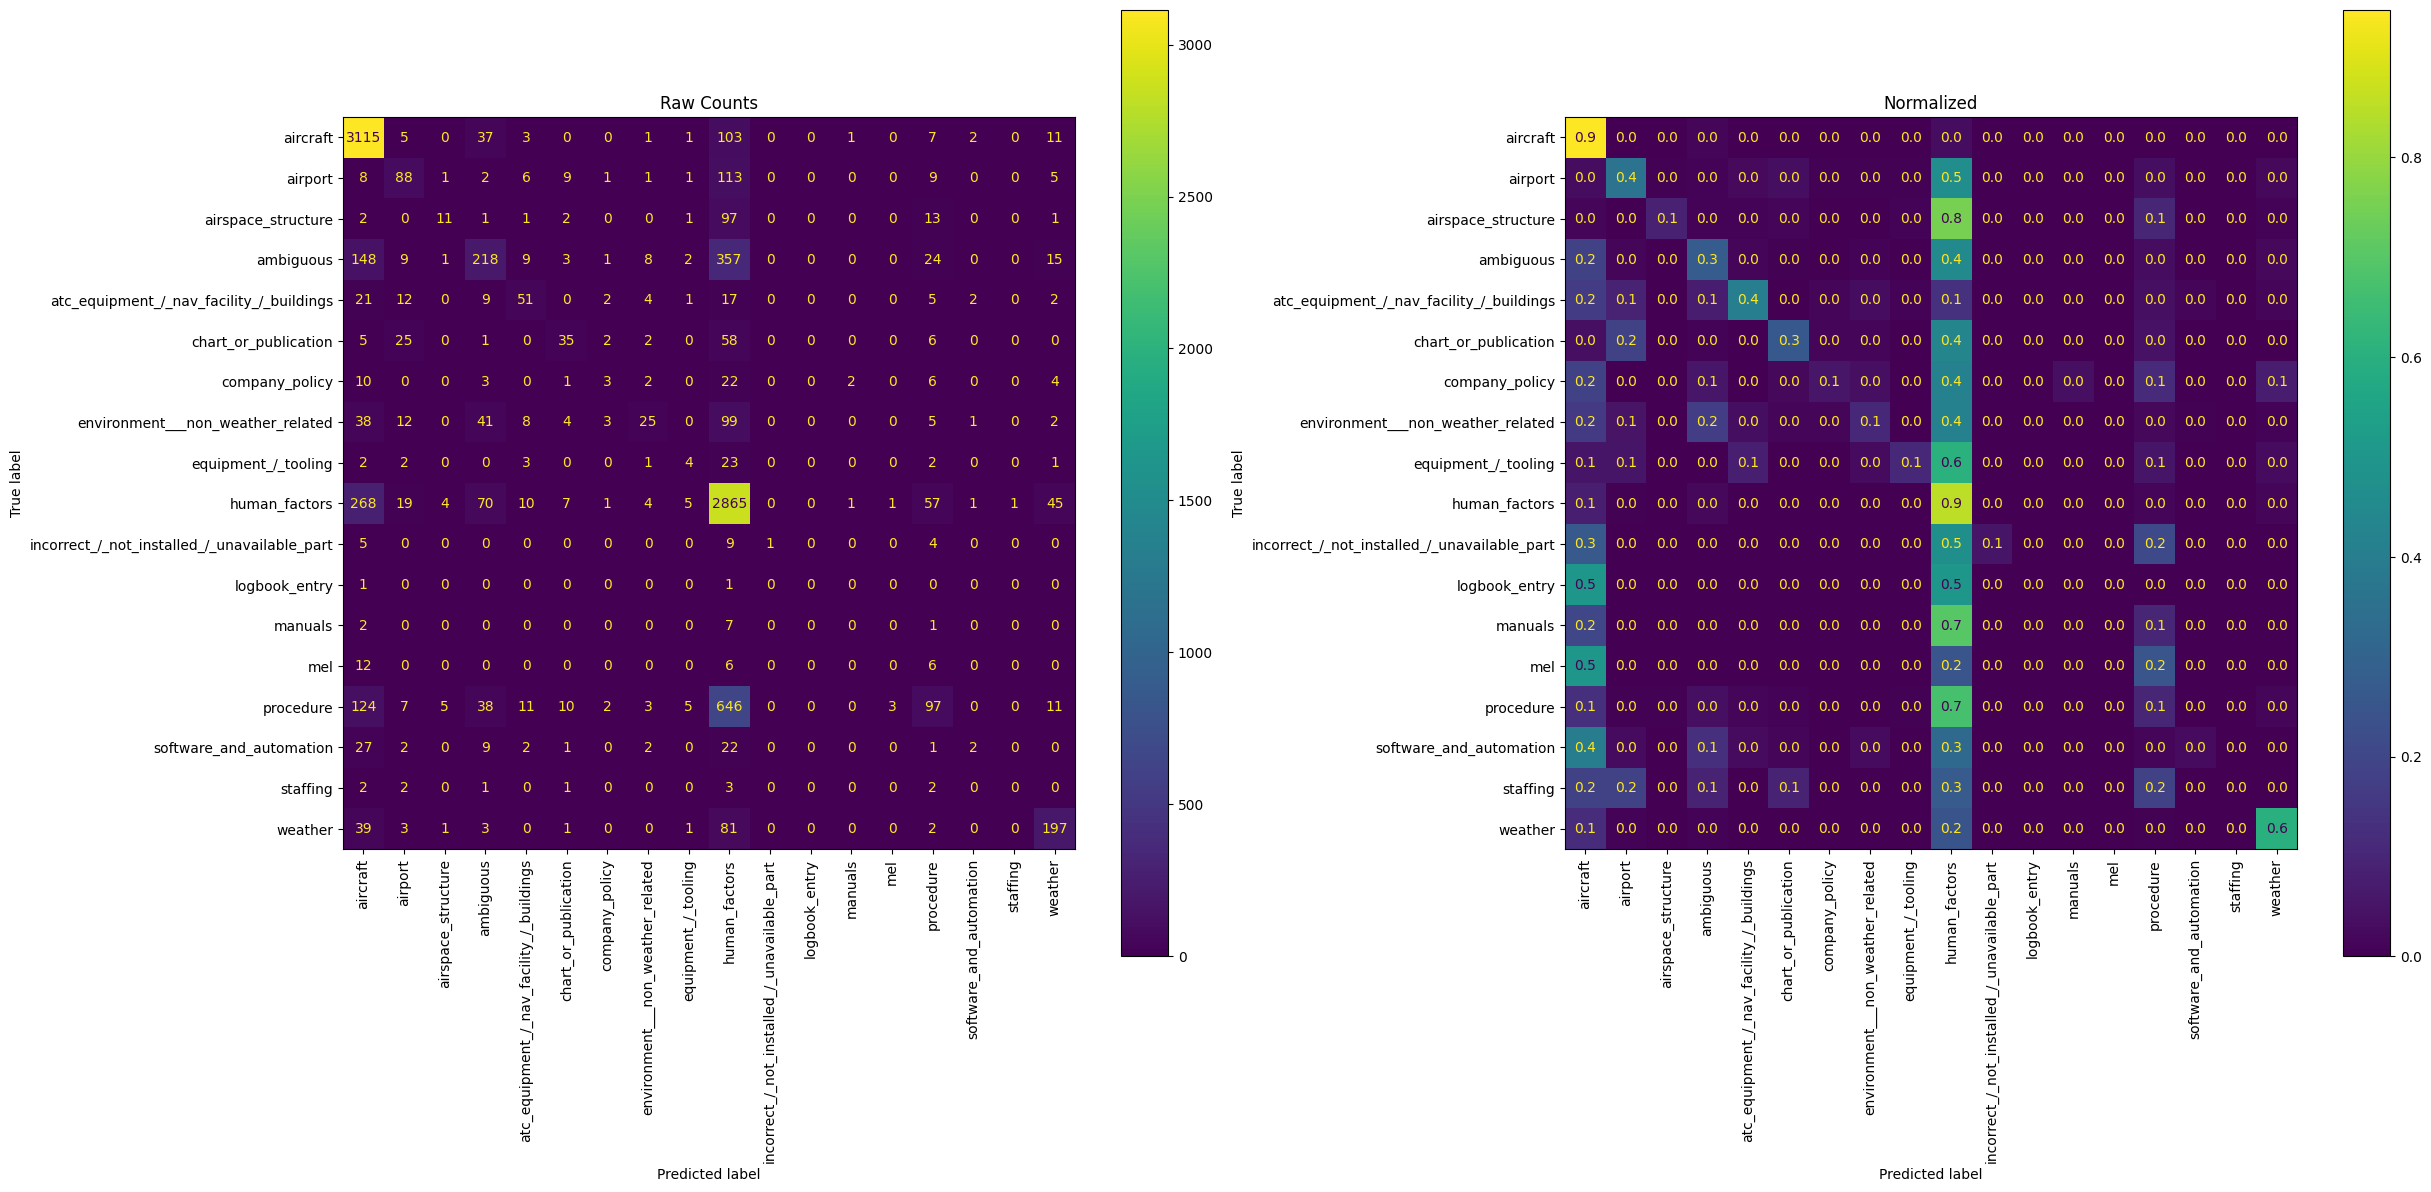

In [9]:
predY = ovr.predict(testX)
utils.visualize_eval(testY, predY, "OVR Unbalanced")

One vs. Rest with SMOTE

In [10]:
svc_bal = SVC()
ovr_bal = OneVsRestClassifier(svc_bal, n_jobs=-1)
smt = SMOTE(k_neighbors=1)

In [11]:
balanced_trainX, balanced_trainY = smt.fit_resample(trainX, trainY)

In [12]:
ovr_bal.fit(balanced_trainX, balanced_trainY)

,estimator,SVC()
,n_jobs,-1
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001


In [13]:
ovr_bal.score(testX, testY)

0.5828414410746998

                                              precision    recall  f1-score   support

                                    aircraft       0.86      0.89      0.88      3286
                                     airport       0.26      0.38      0.31       244
                          airspace_structure       0.10      0.33      0.15       129
                                   ambiguous       0.36      0.30      0.33       795
    atc_equipment_/_nav_facility_/_buildings       0.30      0.37      0.33       126
                        chart_or_publication       0.29      0.31      0.30       134
                              company_policy       0.13      0.17      0.15        53
           environment___non_weather_related       0.21      0.31      0.25       238
                         equipment_/_tooling       0.12      0.21      0.16        38
                               human_factors       0.69      0.51      0.59      3359
incorrect_/_not_installed_/_unavailable_part       0.

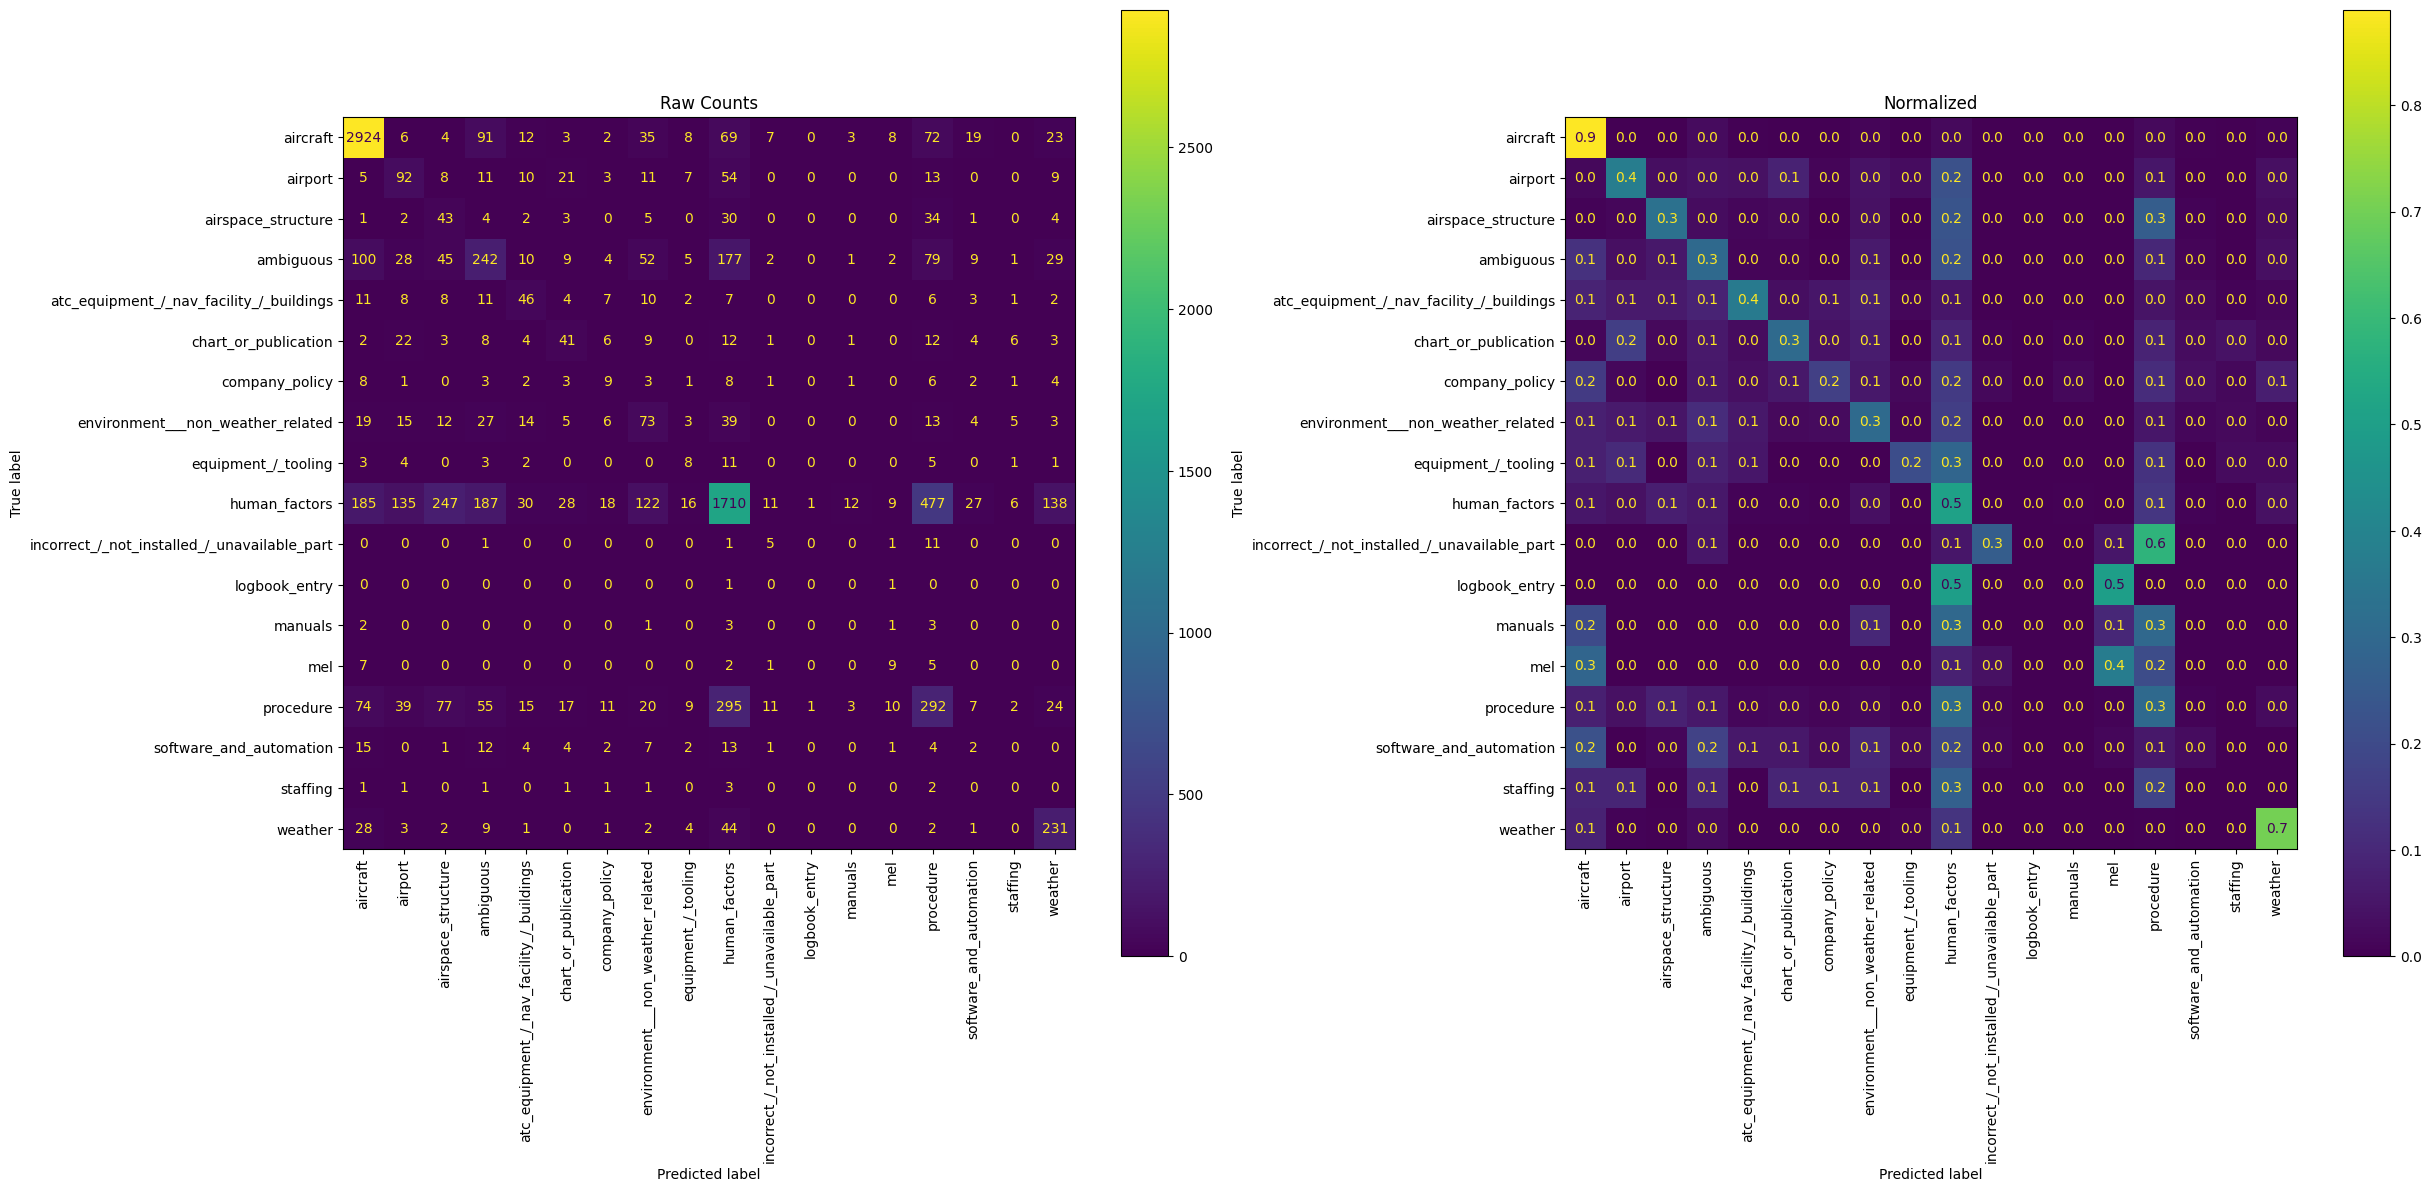

In [14]:
balanced_predY = ovr_bal.predict(testX)
utils.visualize_eval(testY, balanced_predY, "OVR Balanced")

SMOTE (Using more neighbors)

In [ ]:
svc_bal_k10 = SVC()
ovr_bal_k10 = OneVsRestClassifier(svc_bal, n_jobs=-1)
smt_k10 = SMOTE(k_neighbors=5)

In [16]:
train_events_noLB_df = train_events_df[train_events_df["assessments_primary_problem"] != "logbook_entry"]
validation_events_noLB_df = validation_events_df[validation_events_df["assessments_primary_problem"] != "logbook_entry"]
test_events_noLB_df = test_events_df[test_events_df["assessments_primary_problem"] != "logbook_entry"]

In [ ]:
# Remove logbook_entry primary problems to allow use of more neighbors for sample generation
trainX_noLB = train_events_noLB_df.drop(columns="assessments_primary_problem")
trainY_noLB = train_events_noLB_df["assessments_primary_problem"]

testX_noLB = test_events_noLB_df.drop(columns="assessments_primary_problem")
testY_noLB = test_events_noLB_df["assessments_primary_problem"]

trainX_noLB_bal, trainY_noLB_bal = smt_k10.fit_resample(trainX_noLB, trainY_noLB)

: 

In [ ]:
ovr_bal_k10.fit(trainX_noLB_bal, trainY_noLB_bal)

In [ ]:
ovr_bal_k10.score(testX_noLB, testY_noLB)

In [ ]:
predY_noLB = ovr_bal_k10.predict(testX_noLB)
utils.visualize_eval(testY_noLB, predY_noLB, "OVR No Logbook Balanced")